In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState

from flightning import FLIGHTNING_PATH
from flightning.algos import bptt
from flightning.envs import HoveringStateEnv, rollout
from flightning.envs.wrappers import MinMaxObservationWrapper
from flightning.modules import MLP

%matplotlib inline

2025-09-11 13:52:09.775187: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Training a State-based Quadrotor Policy With BPTT

## Seed it

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_bptt = jax.random.split(key, 2)

## Setup the Training Environment

In [3]:
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = HoveringStateEnv(
    max_steps_in_episode=3 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=0.1,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
)
env = MinMaxObservationWrapper(env)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]

472


## Define the Policy Network

In [4]:
policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    initial_scale=0.01,
    action_bias=env.hovering_action,
)
policy_params = policy_net.initialize(key_init)

## Setup the Optimizer and Train State

In [5]:
N = 1000
scheduler = optax.cosine_decay_schedule(1e-2, N)
tx = optax.adam(scheduler)
train_state = TrainState.create(
    apply_fn=policy_net.apply, params=policy_params, tx=tx
)

## Initial Rollout

In [6]:
def get_rollouts(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None))
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions


def policy(obs, key):
    return train_state.apply_fn(train_state.params, obs)

transitions = get_rollouts(env, policy, 10, jax.random.key(3))

/home/yanrui/tempstorage4/rpg_flightning/flightning/envs/hovering_state_env.py:440: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


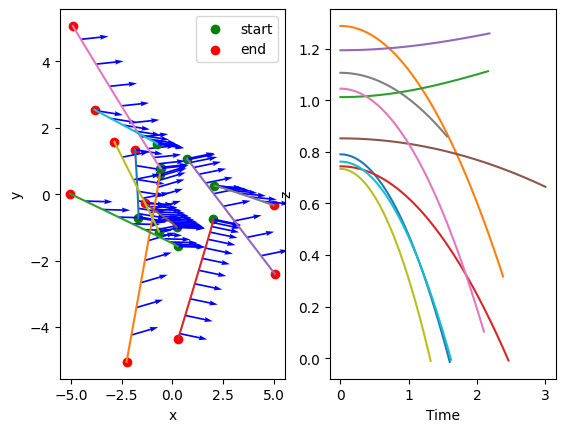

In [7]:
env.plot_trajectories(transitions)

## Train the Policy Using BPTT

In [8]:
time_start = time.time()
res_dict = bptt.train(
    env,
    train_state,
    num_epochs=1000,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=100,
    key=key_bptt,
)
time_train = time.time() - time_start
print(f"Training time: {time_train}")

Episode: 0, Grad max: 6.6816
Episode: 0, Loss: 55.67
Episode: 10, Grad max: 15.8174
Episode: 10, Loss: 33.76
Episode: 20, Grad max: 26.2197
Episode: 20, Loss: 17.37
Episode: 30, Grad max: 23.4915
Episode: 30, Loss: 15.99
Episode: 40, Grad max: 8.7163
Episode: 40, Loss: 14.30
Episode: 50, Grad max: 1.1175
Episode: 50, Loss: 12.26
Episode: 60, Grad max: 1.7341
Episode: 60, Loss: 10.31
Episode: 70, Grad max: 10.6464
Episode: 70, Loss: 163.41
Episode: 80, Grad max: 38.8503
Episode: 80, Loss: 42.54
Episode: 90, Grad max: 51.3963
Episode: 90, Loss: 17.68
Episode: 100, Grad max: 34.5978
Episode: 100, Loss: 14.09
Episode: 110, Grad max: 34.2739
Episode: 110, Loss: 11.52
Episode: 120, Grad max: 9.9028
Episode: 120, Loss: 9.03
Episode: 130, Grad max: 23.5233
Episode: 130, Loss: 9.04
Episode: 140, Grad max: 15.1360
Episode: 140, Loss: 8.38
Episode: 150, Grad max: 20.0114
Episode: 150, Loss: 9.38
Episode: 160, Grad max: 22.1089
Episode: 160, Loss: 9.23
Episode: 170, Grad max: 26.2630
Episode: 170,

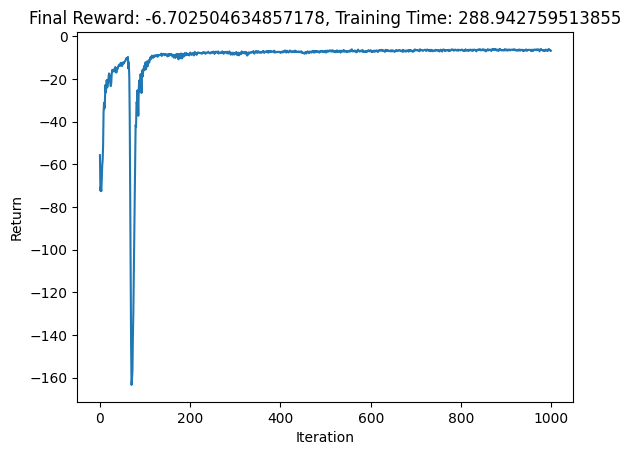

In [9]:
rewards = -res_dict["metrics"]
plt.plot(rewards)
plt.title(f"Final Reward: {rewards[-1]}, Training Time: {time_train}")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

In [10]:
new_train_state = res_dict["runner_state"].train_state

def policy_trained(obs, key):
    return train_state.apply_fn(new_train_state.params, obs)

In [11]:
env_eval = HoveringStateEnv(
    max_steps_in_episode=6 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.05,
    yaw_scale=0.05,
    pitch_roll_scale=0.05,
    omega_std=0.05,
    drone_path=drone_path,
)
env_eval = MinMaxObservationWrapper(env_eval)
transitions_eval = get_rollouts(env_eval, policy_trained, 20, jax.random.key(3))

472


/home/yanrui/tempstorage4/rpg_flightning/flightning/envs/hovering_state_env.py:440: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


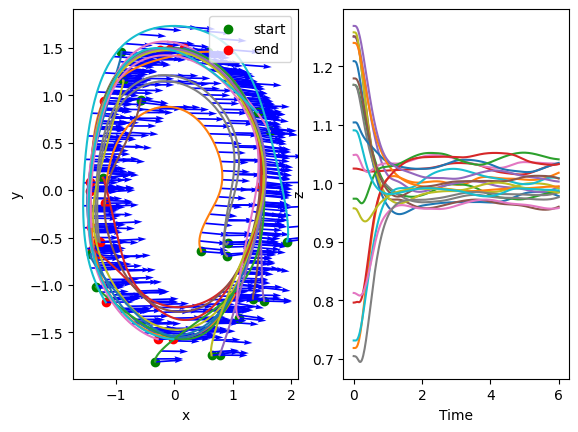

In [12]:
env_eval.plot_trajectories(transitions_eval)

In [13]:
transitions_eval.state.quadrotor_state.v[1][-1,:]

Array([0.7389141 , 0.83765656, 0.02473859], dtype=float32)

In [14]:
transitions_eval.state.quadrotor_state.time_elapsed[1][-1]

AttributeError: 'QuadrotorState' object has no attribute 'time_elapsed'

In [15]:
from orbax.checkpoint import PyTreeCheckpointer
path = FLIGHTNING_PATH + "/../examples/saved_params"
ckptr = PyTreeCheckpointer()
ckptr.save(path, new_train_state.params)

In [ ]:
train_state.apply_fn(new_train_state.params, transitions_eval.obs[10][-14])